In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os 
import torch

In [ ]:
print(os.listdir('../data'))
ds=pd.read_csv('../data/DRIFT_DATA_FULL_hackathon.csv')

ds['time']=pd.to_datetime(ds[['year',	'month',	'day']]) # creat a datetime64
print(ds.columns)
ds=ds.set_index(['time','x_EASE','y_EASE','id_buoy'])

ds=ds.drop(['year',	'month',	'day'],axis=1)
ds

['bathymetry_EASE.csv', 'DRIFT_DATA_FULL.csv', 'DRIFT_DATA_FULL_hackathon.csv', 'DRIFT_DATA_TEST.csv', 'DRIFT_DATA_TEST_ans.csv', 'DRIFT_DATA_TRAIN.csv', 'latitude_EASE.csv', 'longitude_EASE.csv', 'README.txt']
Index(['year', 'month', 'day', 'doy', 'x_EASE', 'y_EASE', 'u_buoy', 'v_buoy',
       'id_buoy', 'u_ERA5', 'v_ERA5', 'sic_CDR', 'h_cs2smos', 'h_piomas',
       'd2c', 'time'],
      dtype='object')


doy    u_buoy     v_buoy    u_ERA5  \
time       x_EASE     y_EASE     id_buoy                                       
1979-02-18 197.656311 204.507797 1905      49  4.514760  12.047400  5.998414   
           147.506958 138.582672 1906      49 -0.797554   1.114740 -6.704156   
           146.834778 120.509880 1913      49  0.643200   0.368754 -6.818630   
           130.993561 129.623672 1914      49 -1.162420   0.243717 -8.825469   
           147.524719 157.382492 1918      49  0.919766   0.025784 -1.079951   
...                                       ...       ...        ...       ...   
2019-12-30 208.421234 142.049896 53005    364 -7.247925  -5.289890 -4.615093   
           145.264023 146.109741 95020    364 -0.913761   2.182150  1.940967   
           191.944336 173.387054 87220    364 -1.462300 -13.284300 -2.627429   
           193.921402 174.408707 7750     364 -0.101372 -11.791700 -2.468425   
           100.407974 159.768845 16461    364  0.000000  -0.000000  1.372457   

                                            v_ERA5   sic_CDR  h_cs2smos  \
time       x_EASE     y_EASE     id_buoy                                  
1979-02-18 197.656311 204.507797 1905     3.617303  0.987723        NaN   
           147.506958 138.582672 1906    -0.321260  0.990195        NaN   
           146.834778 120.509880 1913    -0.674205  0.966372        NaN   
           130.993561 129.623672 1914     1.123955  0.996022        NaN   
           147.524719 157.382492 1918    -1.035410  0.982681        NaN   
...                                            ...       ...        ...   
2019-12-30 208.421234 142.049896 53005   -0.381765  1.000000   1.039972   
           145.264023 146.109741 95020    1.119087  1.000000   2.059716   
           191.944336 173.387054 87220   -6.525005  1.000000   1.425662   
           193.921402 174.408707 7750    -5.363596  1.000000   1.411272   
           100.407974 159.768845 16461    7.310530  0.949975   1.221326   

                                          h_piomas         d2c  
time       x_EASE     y_EASE     id_buoy                        
1979-02-18 197.656311 204.507797 1905     2.535649  375.766965  
           147.506958 138.582672 1906     3.189743  522.523298  
           146.834778 120.509880 1913     2.484009  412.767669  
           130.993561 129.623672 1914     2.474106  362.547379  
           147.524719 157.382492 1918     3.740522  381.025629  
...                                            ...         ...  
2019-12-30 208.421234 142.049896 53005    1.288953  360.491321  
           145.264023 146.109741 95020    1.960349  393.799208  
           191.944336 173.387054 87220    1.643343  731.985737  
           193.921402 174.408707 7750     1.610893  680.057567  
           100.407974 159.768845 16461    1.339197   11.722729  

[424348 rows x 9 columns]

In [ ]:
trainset=pd.read_csv('../data/DRIFT_DATA_TRAIN.csv')

trainset['time']=pd.to_datetime(trainset[['year',	'month',	'day']]) # creat a datetime64
print(trainset.columns)
trainset=trainset.set_index(['time','x_EASE','y_EASE','id_buoy'])

trainset=ds.drop(['year',	'month',	'day'],axis=1)
trainset

Index(['year', 'month', 'day', 'doy', 'x_EASE', 'y_EASE', 'u_buoy', 'v_buoy',
       'id_buoy', 'u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'time'],
      dtype='object')


doy     u_buoy     v_buoy    u_ERA5  \
time       x_EASE     y_EASE     id_buoy                                        
1979-02-18 197.656311 204.507797 1905      49   4.514760  12.047400  5.998414   
           147.506958 138.582672 1906      49  -0.797554   1.114740 -6.704156   
           146.834778 120.509880 1913      49   0.643200   0.368754 -6.818630   
           130.993561 129.623672 1914      49  -1.162420   0.243717 -8.825469   
           147.524719 157.382492 1918      49   0.919766   0.025784 -1.079951   
...                                       ...        ...        ...       ...   
2019-12-30 200.005966 174.816803 16210    364  -1.894280  -0.864665 -1.934895   
           173.589722 117.012932 25560    364 -13.455300 -10.662800 -7.082469   
           208.421234 142.049896 53005    364  -7.247925  -5.289890 -4.615093   
           145.264023 146.109741 95020    364  -0.913761   2.182150  1.940967   
           191.944336 173.387054 87220    364  -1.462300 -13.284300 -2.627429   

                                            v_ERA5   sic_CDR  h_piomas  
time       x_EASE     y_EASE     id_buoy                                
1979-02-18 197.656311 204.507797 1905     3.617303  0.987723  2.535649  
           147.506958 138.582672 1906    -0.321260  0.990195  3.189743  
           146.834778 120.509880 1913    -0.674205  0.966372  2.484009  
           130.993561 129.623672 1914     1.123955  0.996022  2.474106  
           147.524719 157.382492 1918    -1.035410  0.982681  3.740522  
...                                            ...       ...       ...  
2019-12-30 200.005966 174.816803 16210   -1.281953  1.000000  1.467497  
           173.589722 117.012932 25560   -4.199740  1.000000  1.061049  
           208.421234 142.049896 53005   -0.381765  1.000000  1.288953  
           145.264023 146.109741 95020    1.119087  1.000000  1.960349  
           191.944336 173.387054 87220   -6.525005  1.000000  1.643343  

[339156 rows x 7 columns]

In [9]:
testset=pd.read_csv('../data/DRIFT_DATA_TEST.csv')

testset['time']=pd.to_datetime(testset[['year',	'month',	'day']]) # creat a datetime64
print(testset.columns)
testset=testset.set_index(['time','x_EASE','y_EASE','id_buoy'])

testset=testset.drop(['year',	'month',	'day'],axis=1)
testset

Index(['year', 'month', 'day', 'doy', 'x_EASE', 'y_EASE', 'u_buoy', 'v_buoy',
       'id_buoy', 'u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'time'],
      dtype='object')


,,,,doy,u_buoy,v_buoy,u_ERA5,v_ERA5,sic_CDR,h_piomas
time,x_EASE,y_EASE,id_buoy,,,,,,,
2000-09-03,155.338104,135.642914,20859,247,0.581564,5.089090,2.442403,1.127142,0.996916,2.090739
1991-12-13,137.390686,109.197037,7102,347,-7.343290,5.486450,-1.543713,7.514323,1.000000,3.126633
2019-10-12,143.100266,135.374527,28260,285,-9.617448,1.464240,1.953833,2.135191,0.995579,1.072999
2006-01-12,136.624252,124.138580,2416,12,-3.054050,-4.868510,-4.295371,-1.320883,1.000000,2.497801
2019-06-30,125.033562,139.533203,30190,181,-5.769730,-7.234500,-2.547196,-2.842972,0.608846,0.995868
...,...,...,...,...,...,...,...,...,...,...
2018-10-04,199.609039,153.454193,80340,277,0.125740,12.420890,-2.484974,4.338783,0.470374,0.325952
2019-11-05,100.408081,159.768951,16461,309,-0.002208,0.008300,-4.538159,4.005265,0.974692,0.313667
2007-06-27,152.641693,161.907364,5311,178,-6.588125,1.260437,-3.090631,2.086311,1.000000,3.007476


In [10]:
339156+84789 

423945

In [ ]:
ds_reset = ds.reset_index()

# Group by all iadex columns and aggregate — adjust mean() to suit your needs
ds_dedup = (
    ds_reset
    .groupby(['time', 'x_EASE', 'y_EASE', 'id_buoy'])
    .mean()  # or .median(), .first(), .last()
)

ds_dedup.to

doy    u_buoy     v_buoy  \
time       x_EASE     y_EASE     id_buoy                               
1979-02-18 130.993561 129.623672 1914      49.0 -1.162420   0.243717   
           146.834778 120.509880 1913      49.0  0.643200   0.368754   
           147.506958 138.582672 1906      49.0 -0.797554   1.114740   
           147.524719 157.382492 1918      49.0  0.919766   0.025784   
           197.656311 204.507797 1905      49.0  4.514760  12.047400   
...                                         ...       ...        ...   
2019-12-30 213.399780 168.042694 12210    364.0 -1.626900   2.990300   
           213.472595 213.374847 74637    364.0 -0.819455  31.283001   
           221.637543 196.713364 74640    364.0 -4.362884  36.536999   
           228.184860 205.325592 52967    364.0 -2.311075  30.482250   
           235.001434 157.511642 74645    364.0 -0.004945   0.005122   

                                            u_ERA5     v_ERA5   sic_CDR  \
time       x_EASE     y_EASE     id_buoy                                  
1979-02-18 130.993561 129.623672 1914    -8.825469   1.123955  0.996022   
           146.834778 120.509880 1913    -6.818630  -0.674205  0.966372   
           147.506958 138.582672 1906    -6.704156  -0.321260  0.990195   
           147.524719 157.382492 1918    -1.079951  -1.035410  0.982681   
           197.656311 204.507797 1905     5.998414   3.617303  0.987723   
...                                            ...        ...       ...   
2019-12-30 213.399780 168.042694 12210   -0.253610   4.749857  1.000000   
           213.472595 213.374847 74637    0.141422  12.272284  0.932317   
           221.637543 196.713364 74640   -1.130047  11.615884  1.000000   
           228.184860 205.325592 52967   -1.820957  15.016733  0.410847   
           235.001434 157.511642 74645   -2.942931   2.754206  0.543750   

                                          h_cs2smos  h_piomas         d2c  
time       x_EASE     y_EASE     id_buoy                                   
1979-02-18 130.993561 129.623672 1914           NaN  2.474106  362.547379  
           146.834778 120.509880 1913           NaN  2.484009  412.767669  
           147.506958 138.582672 1906           NaN  3.189743  522.523298  
           147.524719 157.382492 1918           NaN  3.740522  381.025629  
           197.656311 204.507797 1905           NaN  2.535649  375.766965  
...                                             ...       ...         ...  
2019-12-30 213.399780 168.042694 12210     1.058268  1.279627  292.919034  
           213.472595 213.374847 74637     0.542991  0.757001  110.007489  
           221.637543 196.713364 74640     0.785720  1.114832  120.317901  
           228.184860 205.325592 52967     0.242600  0.839434  171.210682  
           235.001434 157.511642 74645          NaN  0.043123   44.807516  

[423624 rows x 9 columns]

In [ ]:
dup = ds.reset_index().duplicated(subset=['time', 'x_EASE', 'y_EASE'])
duplicate_rows = ds.reset_index()[dup]
print(f"Found {dup.sum()} duplicate rows")
print(duplicate_rows.head())


Found 2778 duplicate rows
            time      x_EASE      y_EASE  id_buoy  doy    u_buoy    v_buoy  \
16823 1988-05-22  210.347031  186.108398     8879  143 -8.231975  5.623675   
29775 1990-12-02  213.732895  167.960724    11104  336  0.244776  7.203065   
29777 1990-12-02  213.732895  167.960419    11104  336  0.247955  7.211545   
29779 1990-12-02  210.506607  175.074509    11108  336  0.052275  6.850560   
29781 1990-12-02  210.505600  175.071915    11108  336  0.065697  6.926855   

         u_ERA5    v_ERA5   sic_CDR  h_cs2smos  h_piomas         d2c  
16823 -3.116273  4.154235  1.000000        NaN  2.990759  334.693779  
29775 -1.161826  6.510078  0.993518        NaN  1.665080  288.286953  
29777 -1.161826  6.510078  0.993518        NaN  1.665080  288.292272  
29779  0.106890  4.955213  1.000000        NaN  1.751073  266.714750  
29781  0.106890  4.955213  1.000000        NaN  1.751073  266.751224  


In [87]:
ds_reset = ds.reset_index()

dup_mask = ds_reset.duplicated(
    subset=['time', 'x_EASE', 'y_EASE', 'id_buoy'], 
    keep=False
)

print(f"True duplicates: {dup_mask.sum()}")
print(ds_reset[dup_mask].sort_values(['time', 'x_EASE', 'y_EASE', 'id_buoy']))

True duplicates: 1292
             time      x_EASE      y_EASE  id_buoy  doy    u_buoy     v_buoy  \
29782  1990-12-02  162.309982  117.792122    12782  336  4.650395   1.116861   
29783  1990-12-02  162.309982  117.792122    12782  336  4.650395   1.116861   
29780  1990-12-02  210.505600  175.071915    11108  336  0.065697   6.926855   
29781  1990-12-02  210.505600  175.071915    11108  336  0.065697   6.926855   
29778  1990-12-02  210.506607  175.074509    11108  336  0.052275   6.850560   
...           ...         ...         ...      ...  ...       ...        ...   
386163 2018-11-06  203.558365  206.439590    45780  310  7.591245 -16.354851   
388673 2018-12-02  203.139496  205.130127    45780  336 -4.996030  -3.027740   
388674 2018-12-02  203.139496  205.130127    45780  336 -4.985963  -3.019263   
388671 2018-12-02  203.140503  205.130127    45780  336 -5.014730  -3.045755   
388672 2018-12-02  203.140503  205.130127    45780  336 -5.004663  -3.037278   

          u_ERA5 

In [ ]:
dup = ds.duplicated()
dupidx=[]
for i,m in enumerate(dup.values):
    if m==True:
        dupidx.append(i)
dupidx=np.array(dupidx)


print(ds.iloc(dup))

[ 29775  29777  29779  29781  29783  29805  29807  29809  29811  29813
  29814  29815  29827  29829  29840  29842  29844  29846  29862  29864
  29880  29881  29914  29915  29916  29925  29926  29946  29948  29950
  29952  29980  29981  29982  29984  29985  29986  29999  30001  30008
  30010  30016  30018  30020  30021  30022  30024  30026  30050  30052
  30054  30055  30056  30059  30060  30077  30079  30086  30088  30090
  30092  30094  30095  30096  30098  30100  30102  30104  30110  30112
  30119  30121  30123  30125  30127  30128  30129  30131  30133  30140
  30153  30155  30157  30159  30161  30163  30187  30188  30189  30195
  30196  30197  30204  30206  30220  30222  30228  30230  30232  30234
  30239  30240  30243  30245  30247  30249  30256  30258  30260  30262
  30264  30265  30266  30268  30275  30276  30292  30294  30300  30301
  30302  30306  30307  30322  30324  30326  30328  30330  30331  30332
  30343  30344  30347  30359  30361  30363  30364  30365  30391  30393
  3039

TypeError: unhashable type: 'Series'

In [94]:
lat2d = pd.read_csv('../data/latitude_EASE.csv', header=None).values   # shape (360, 361)
lon2d = pd.read_csv('../data/longitude_EASE.csv', header=None).values   # shape (360, 361)

# Build a clean xarray Dataset with x/y as the actual dimensions
# and lat/lon as 2D coordinate arrays hanging off them
ds_grid = xr.Dataset(
    coords={
        "lat": (["y", "x"], lat2d),
        "lon": (["y", "x"], lon2d),
    }
)

print(ds_grid)
print(f"Lat range: {lat2d.min():.2f} to {lat2d.max():.2f}")
print(f"Lon range: {lon2d.min():.2f} to {lon2d.max():.2f}")

<xarray.Dataset> Size: 2MB
Dimensions:  (y: 361, x: 361)
Coordinates:
    lat      (y, x) float64 1MB 29.9 30.08 30.26 30.45 ... 30.26 30.08 29.9
    lon      (y, x) float64 1MB -135.0 -135.2 -135.3 -135.5 ... 44.68 44.84 45.0
Dimensions without coordinates: y, x
Data variables:
    *empty*
Lat range: 29.90 to 90.00
Lon range: -179.68 to 180.00


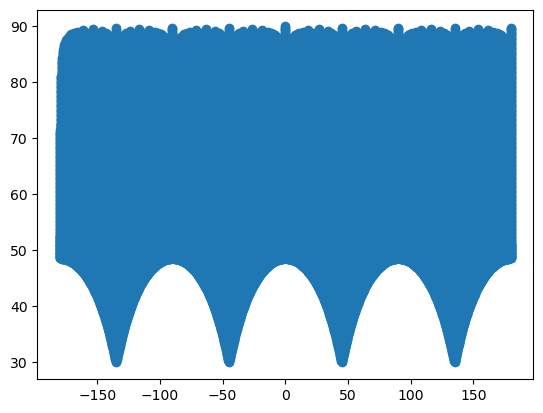

In [104]:
plt.scatter(ds_grid.lon,ds_grid.lat)

In [92]:



latt =pd.read_csv('../data/latitude_EASE.csv')
lonn=pd.read_csv('../data/longitude_EASE.csv')
latt




,29.89693,30.08075,30.26388,30.44633,30.62809,30.80915,30.98952,31.1692,31.34818,31.52646,...,31.52646.1,31.34818.1,31.1692.1,30.98952.1,30.80915.1,30.62809.1,30.44633.1,30.26388.1,30.08075.1,29.89693.1
0,30.08075,30.26491,30.44839,30.63118,30.81328,30.99470,31.17542,31.35545,31.53479,31.71343,...,31.71343,31.53479,31.35545,31.17542,30.99470,30.81328,30.63118,30.44839,30.26491,30.08075
1,30.26388,30.44839,30.63221,30.81535,30.99780,31.17957,31.36065,31.54103,31.72073,31.89973,...,31.89973,31.72073,31.54103,31.36065,31.17957,30.99780,30.81535,30.63221,30.44839,30.26388
2,30.44633,30.63118,30.81535,30.99884,31.18164,31.36376,31.54520,31.72594,31.90599,32.08535,...,32.08535,31.90599,31.72594,31.54520,31.36376,31.18164,30.99884,30.81535,30.63118,30.44633
3,30.62809,30.81328,30.99780,31.18164,31.36480,31.54728,31.72907,31.91017,32.09059,32.27031,...,32.27031,32.09059,31.91017,31.72907,31.54728,31.36480,31.18164,30.99780,30.81328,30.62809
4,30.80915,30.99470,31.17957,31.36376,31.54728,31.73011,31.91226,32.09373,32.27451,32.45459,...,32.45459,32.27451,32.09373,31.91226,31.73011,31.54728,31.36376,31.17957,30.99470,30.80915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,30.62809,30.81328,30.99780,31.18164,31.36480,31.54728,31.72907,31.91017,32.09059,32.27031,...,32.27031,32.09059,31.91017,31.72907,31.54728,31.36480,31.18164,30.99780,30.81328,30.62809
356,30.44633,30.63118,30.81535,30.99884,31.18164,31.36376,31.54520,31.72594,31.90599,32.08535,...,32.08535,31.90599,31.72594,31.54520,31.36376,31.18164,30.99884,30.81535,30.63118,30.44633
357,30.26388,30.44839,30.63221,30.81535,30.99780,31.17957,31.36065,31.54103,31.72073,31.89973,...,31.89973,31.72073,31.54103,31.36065,31.17957,30.99780,30.81535,30.63221,30.44839,30.26388
358,30.08075,30.26491,30.44839,30.63118,30.81328,30.99470,31.17542,31.35545,31.53479,31.71343,...,31.71343,31.53479,31.35545,31.17542,30.99470,30.81328,30.63118,30.44839,30.26491,30.08075


In [56]:
dsxr

<xarray.DataArray (dim_0: 424348, dim_1: 15)> Size: 51MB
array([[1.97900000e+03, 2.00000000e+00, 1.80000000e+01, ...,
                   nan, 2.53564899e+00, 3.75766965e+02],
       [1.97900000e+03, 2.00000000e+00, 1.80000000e+01, ...,
                   nan, 3.18974266e+00, 5.22523298e+02],
       [1.97900000e+03, 2.00000000e+00, 1.80000000e+01, ...,
                   nan, 2.48400856e+00, 4.12767669e+02],
       ...,
       [2.01900000e+03, 1.20000000e+01, 3.00000000e+01, ...,
        1.42566157e+00, 1.64334303e+00, 7.31985737e+02],
       [2.01900000e+03, 1.20000000e+01, 3.00000000e+01, ...,
        1.41127208e+00, 1.61089281e+00, 6.80057567e+02],
       [2.01900000e+03, 1.20000000e+01, 3.00000000e+01, ...,
        1.22132631e+00, 1.33919699e+00, 1.17227290e+01]],
      shape=(424348, 15))
Coordinates:
  * dim_0    (dim_0) int64 3MB 0 1 2 3 4 ... 424343 424344 424345 424346 424347
  * dim_1    (dim_1) object 120B 'year' 'month' 'day' ... 'h_piomas' 'd2c'